<a href="https://colab.research.google.com/github/marinhotechdev/lista01_ClickBoostMarketing/blob/main/lista01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# Teste linha 01
"""
Uma empresa fictícia de marketing digital chamada ClickBoost Marketing gerencia campanhas de anúncios online para diversos clientes. Um dos principais indicadores de desempenho dessas campanhas é o número de cliques obtidos a partir da quantidade de anúncios exibidos.

"""

'\nUma empresa fictícia de marketing digital chamada ClickBoost Marketing gerencia campanhas de anúncios online para diversos clientes. Um dos principais indicadores de desempenho dessas campanhas é o número de cliques obtidos a partir da quantidade de anúncios exibidos.\n\n'

In [8]:
import pandas as pd

# 2. Carregue o arquivo 'marketing.csv' em um DataFrame do pandas.
df = pd.read_csv('/content/marketing.csv')

# 3. Exiba as primeiras 5 linhas do DataFrame.
print("Primeiras 5 linhas do DataFrame:")
print(df.head())
print("\n" + "-" * 30 + "\n")

# 4. Verifique as informações gerais do DataFrame.
print("Informações gerais do DataFrame:")
df.info()
print("\n" + "-" * 30 + "\n")

# 5. Obtenha estatísticas descritivas para as colunas numéricas do DataFrame.
print("Estatísticas descritivas do DataFrame:")
print(df.describe())

Primeiras 5 linhas do DataFrame:
   anuncios  cliques
0       107      315
1       184      613
2        97      352
3        19       98
4       111      322

------------------------------

Informações gerais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   anuncios  100 non-null    int64
 1   cliques   100 non-null    int64
dtypes: int64(2)
memory usage: 1.7 KB

------------------------------

Estatísticas descritivas do DataFrame:
         anuncios     cliques
count  100.000000  100.000000
mean   100.780000  315.320000
std     59.368491  185.166094
min      6.000000   30.000000
25%     53.750000  157.750000
50%     96.500000  310.500000
75%    154.500000  463.250000
max    196.000000  660.000000


In [9]:
clicks_per_ad = df.groupby('anuncios')['cliques'].sum()
sorted_clicks = clicks_per_ad.sort_values(ascending=False)

print("Anúncios classificados por total de cliques (Top 10):")
print(sorted_clicks.head(10))

Anúncios classificados por total de cliques (Top 10):
anuncios
194    3057
192    2425
179    1103
135     890
134     814
136     782
115     771
108     745
93      648
107     638
Name: cliques, dtype: int64


/tmp/ipykernel_202/3818223671.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_clicks.head(10).index, y=sorted_clicks.head(10).values, palette='viridis')


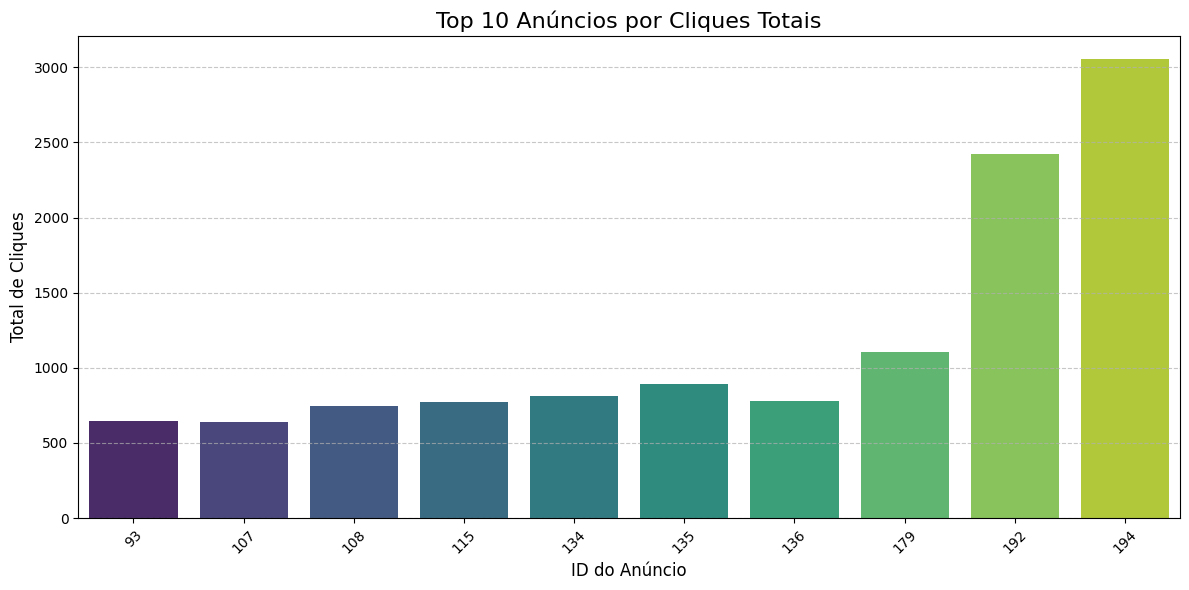

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crie um gráfico de barras para os 10 anúncios com mais cliques
plt.figure(figsize=(12, 6))
sns.barplot(x=sorted_clicks.head(10).index, y=sorted_clicks.head(10).values, palette='viridis')

# Defina o título e os rótulos dos eixos
plt.title('Top 10 Anúncios por Cliques Totais', fontsize=16)
plt.xlabel('ID do Anúncio', fontsize=12)
plt.ylabel('Total de Cliques', fontsize=12)
plt.xticks(rotation=45) # Rotaciona os rótulos do eixo x para melhor leitura
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

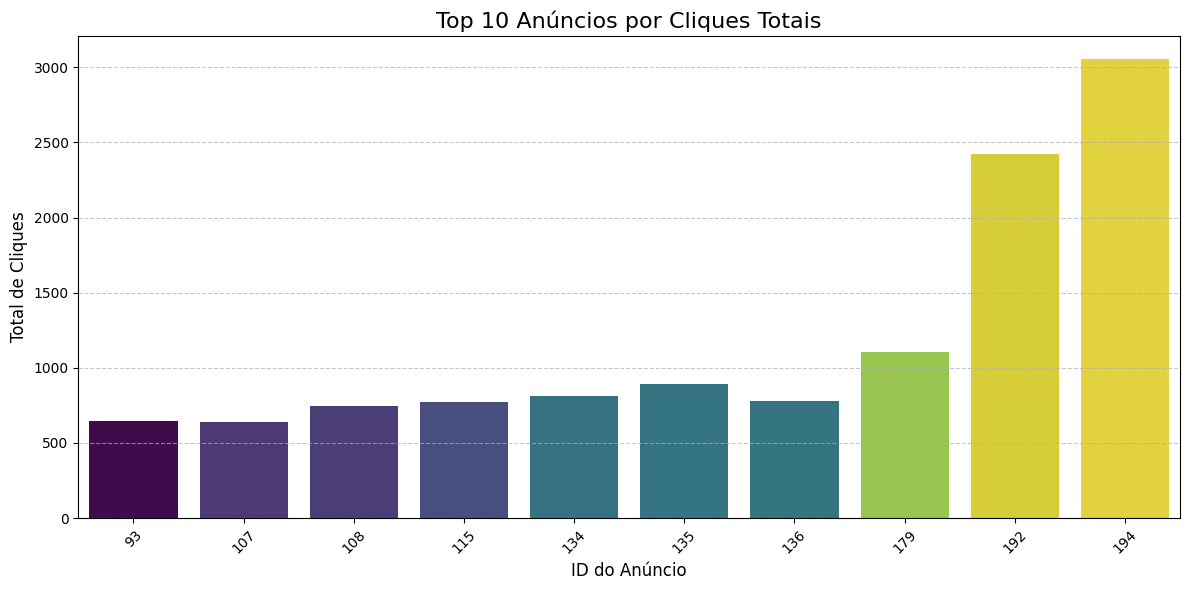

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crie um gráfico de barras para os 10 anúncios com mais cliques
plt.figure(figsize=(12, 6))
sns.barplot(x=sorted_clicks.head(10).index, y=sorted_clicks.head(10).values, palette='viridis', hue=sorted_clicks.head(10).index, legend=False)

# Defina o título e os rótulos dos eixos
plt.title('Top 10 Anúncios por Cliques Totais', fontsize=16)
plt.xlabel('ID do Anúncio', fontsize=12)
plt.ylabel('Total de Cliques', fontsize=12)
plt.xticks(rotation=45) # Rotaciona os rótulos do eixo x para melhor leitura
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

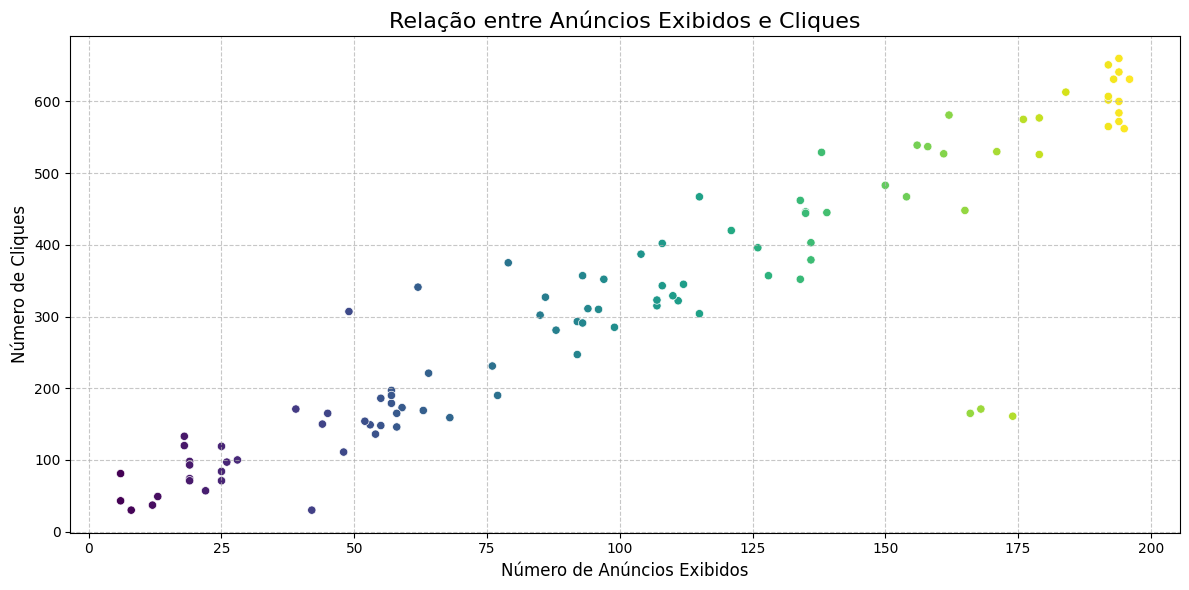

In [12]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='anuncios', y='cliques', data=df, hue='anuncios', palette='viridis', legend=False)
plt.title('Relação entre Anúncios Exibidos e Cliques', fontsize=16)
plt.xlabel('Número de Anúncios Exibidos', fontsize=12)
plt.ylabel('Número de Cliques', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [13]:
from sklearn.model_selection import train_test_split

# Definir as variáveis preditoras (features) e a variável alvo (target)
X = df[['anuncios']]  # X deve ser um DataFrame 2D para sklearn
y = df['cliques']

# Dividir os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_train: (80, 1)
Shape de X_test: (20, 1)
Shape de y_train: (80,)
Shape de y_test: (20,)


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 2. Crie uma instância do modelo LinearRegression.
model = LinearRegression()

# 3. Treine o modelo usando os dados de treinamento (X_train e y_train).
model.fit(X_train, y_train)

# 4. Use o modelo treinado para fazer previsões no conjunto de teste.
y_pred = model.predict(X_test)

# 5. Calcule as métricas de avaliação:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# 6. Imprima os valores calculados de MSE, R-quadrado e MAE.
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Squared Error (MSE): 10048.00
R-squared (R2): 0.62
Mean Absolute Error (MAE): 63.82


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Carregue o arquivo 'marketing.csv' em um DataFrame do pandas.
df = pd.read_csv('/content/marketing.csv')

# Redefinir as variáveis preditoras (features) e a variável alvo (target)
X = df[['anuncios']]  # X deve ser um DataFrame 2D para sklearn
y = df['cliques']

# Dividir os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crie uma instância do modelo LinearRegression.
model = LinearRegression()

# Treine o modelo usando os dados de treinamento (X_train e y_train).
model.fit(X_train, y_train)

# Exibir o coeficiente angular (slope) e o intercepto (intercept)
print(f"Coeficiente Angular (Slope): {model.coef_[0]:.2f}")
print(f"Intercepto (Intercept): {model.intercept_:.2f}")

# Interpretação
print("\nInterpretação:")
print(f"O coeficiente angular de {model.coef_[0]:.2f} indica que, em média, para cada anúncio adicional exibido, o número de cliques aumenta em aproximadamente {model.coef_[0]:.2f}.")
print(f"O intercepto de {model.intercept_:.2f} representa o número estimado de cliques quando nenhum anúncio é exibido, ou seja, o valor base de cliques (embora no contexto real de marketing, 0 anúncios geralmente resultaria em 0 cliques, então este valor é mais uma referência do modelo).")

Coeficiente Angular (Slope): 2.86
Intercepto (Intercept): 28.21

Interpretação:
O coeficiente angular de 2.86 indica que, em média, para cada anúncio adicional exibido, o número de cliques aumenta em aproximadamente 2.86.
O intercepto de 28.21 representa o número estimado de cliques quando nenhum anúncio é exibido, ou seja, o valor base de cliques (embora no contexto real de marketing, 0 anúncios geralmente resultaria em 0 cliques, então este valor é mais uma referência do modelo).


In [16]:
import numpy as np

# 1. Escolha um valor hipotético para o número de anúncios exibidos
novo_anuncios = 150

# 2. Crie um array NumPy ou um DataFrame pandas com este valor na forma correta (2D)
# O modelo espera um input 2D, mesmo que seja apenas uma feature e uma amostra.
novo_anuncios_array = np.array([[novo_anuncios]])

# 3. Use o método .predict() do modelo treinado para obter a previsão de cliques.
previsao_cliques = model.predict(novo_anuncios_array)

# 4. Imprima o número de anúncios utilizado para a previsão e o número de cliques previsto.
print(f"Para {novo_anuncios} anúncios exibidos, o número de cliques previsto é de aproximadamente {previsao_cliques[0]:.2f}.")

Para 150 anúncios exibidos, o número de cliques previsto é de aproximadamente 457.92.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [17]:
import numpy as np
import pandas as pd # Import pandas to create a DataFrame for prediction input

# 1. Escolha um valor hipotético para o número de anúncios exibidos
novo_anuncios = 150

# 2. Crie um array NumPy ou um DataFrame pandas com este valor na forma correta (2D)
# Para evitar o UserWarning, o input deve ter o mesmo formato (com nomes de colunas) que o X_train
novo_anuncios_df = pd.DataFrame([[novo_anuncios]], columns=['anuncios'])

# 3. Use o método .predict() do modelo treinado para obter a previsão de cliques.
previsao_cliques = model.predict(novo_anuncios_df)

# 4. Imprima o número de anúncios utilizado para a previsão e o número de cliques previsto.
print(f"Para {novo_anuncios} anúncios exibidos, o número de cliques previsto é de aproximadamente {previsao_cliques[0]:.2f}.")

Para 150 anúncios exibidos, o número de cliques previsto é de aproximadamente 457.92.


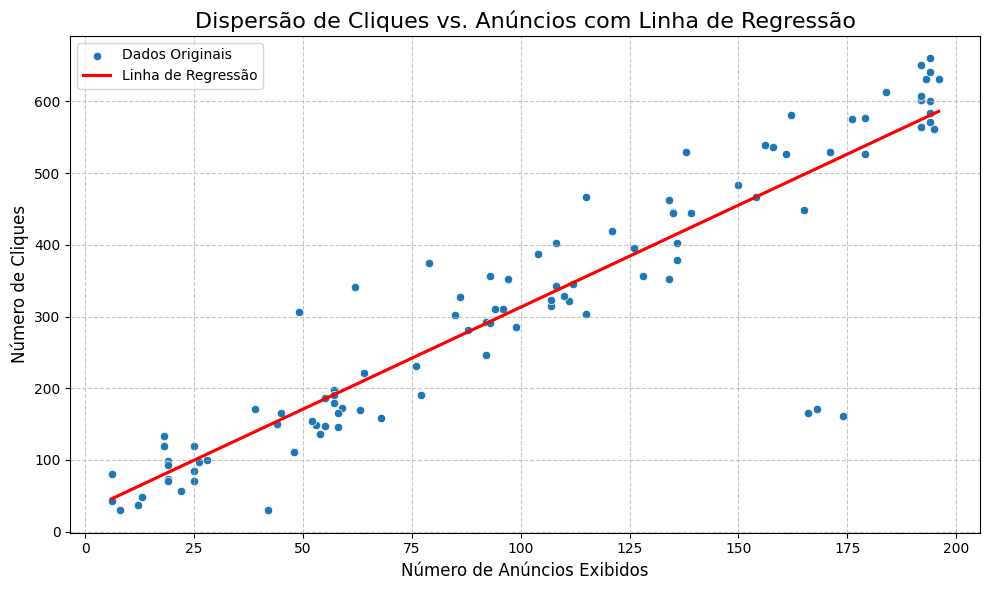

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Crie um gráfico de dispersão (scatterplot) usando os dados originais do DataFrame df
plt.figure(figsize=(10, 6))
sns.scatterplot(x='anuncios', y='cliques', data=df, label='Dados Originais')

# 3. Sobreponha a linha de regressão linear no mesmo gráfico usando sns.regplot()
sns.regplot(x='anuncios', y='cliques', data=df, color='red', scatter=False, ci=False, label='Linha de Regressão')

# 4. Adicione um título ao gráfico
plt.title('Dispersão de Cliques vs. Anúncios com Linha de Regressão', fontsize=16)

# 5. Adicione rótulos aos eixos x e y
plt.xlabel('Número de Anúncios Exibidos', fontsize=12)
plt.ylabel('Número de Cliques', fontsize=12)

# Adicionar legenda e grade
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# 6. Exiba o gráfico
plt.show()